# 02 — Exploratory Data Analysis (Stage 4)
Figures are produced by `src/eda.py` on the cleaned 5-class data (9,950 rows). EDA is descriptive only; nothing is fitted here.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import Image, display
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
FIG = ROOT / 'figures'; REP = ROOT / 'reports'

In [2]:
from src import eda
eda.main()

Class distribution:
               count  percent
Failure Type                
No Failure     9643    96.91
TWF              43     0.43
HDF             106     1.07
PWF              80     0.80
OSF              78     0.78



Correlation matrix:
                          Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]
Air temperature [K]                    1.000                    0.876                   0.025       -0.017            0.013
Process temperature [K]                0.876                    1.000                   0.021       -0.016            0.013
Rotational speed [rpm]                 0.025                    0.021                   1.000       -0.876            0.003
Torque [Nm]                           -0.017                   -0.016                  -0.876        1.000           -0.010
Tool wear [min]                        0.013                    0.013                   0.003       -0.010            1.000

Failure-type rate (%) within each product Type:
 Failure Type  No Failure    TWF    HDF    PWF    OSF
Type                                                
L                 96.397  0.419  1.139  0.821  1.223
M                 97.554 


Median feature values by class:
               Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Temp difference [K]  Power [W]  Tool wear × torque [min·Nm]
Failure Type                                                                                                                                                                 
No Failure                 300.00                    310.0                  1507.0        39.80            107.0                  9.8    6243.04                      3951.20
TWF                        300.40                    310.3                  1524.0        37.50            215.0                  9.6    5976.25                      7786.80
HDF                        302.40                    310.7                  1349.0        51.75             99.0                  8.3    7273.24                      5313.45
PWF                        300.25                    310.2                  1403.5        62.40 

## 4.1 Target distribution

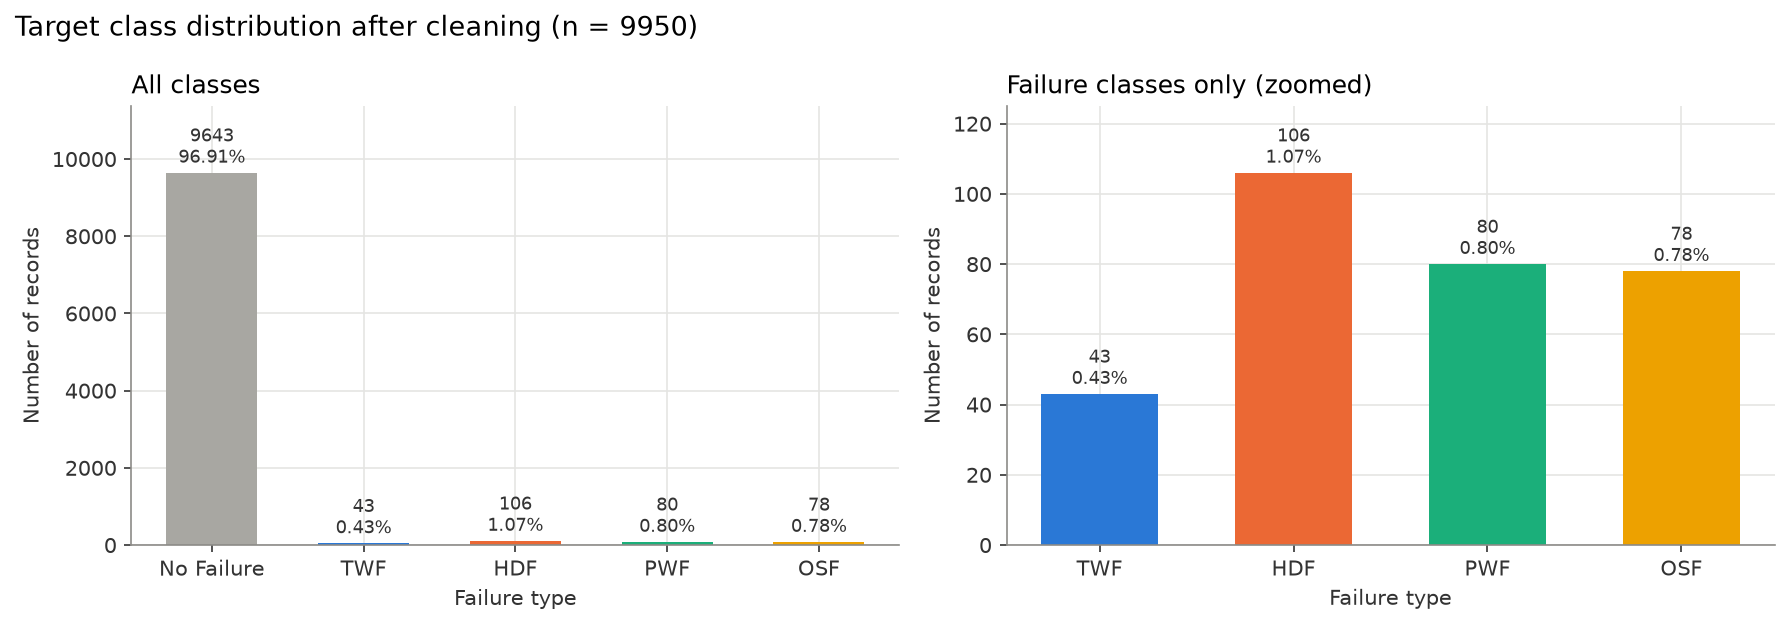

In [3]:
display(Image(filename=str(FIG / '04_class_distribution.png'), width=950))

**Finding.** No Failure is 96.9% of records; the four failure modes together are ~3.1%, and TWF has only 43 examples. Accuracy is therefore uninformative (always predicting No Failure scores ~97%), so Macro F1 is the primary metric.

## 4.2 Numerical distributions

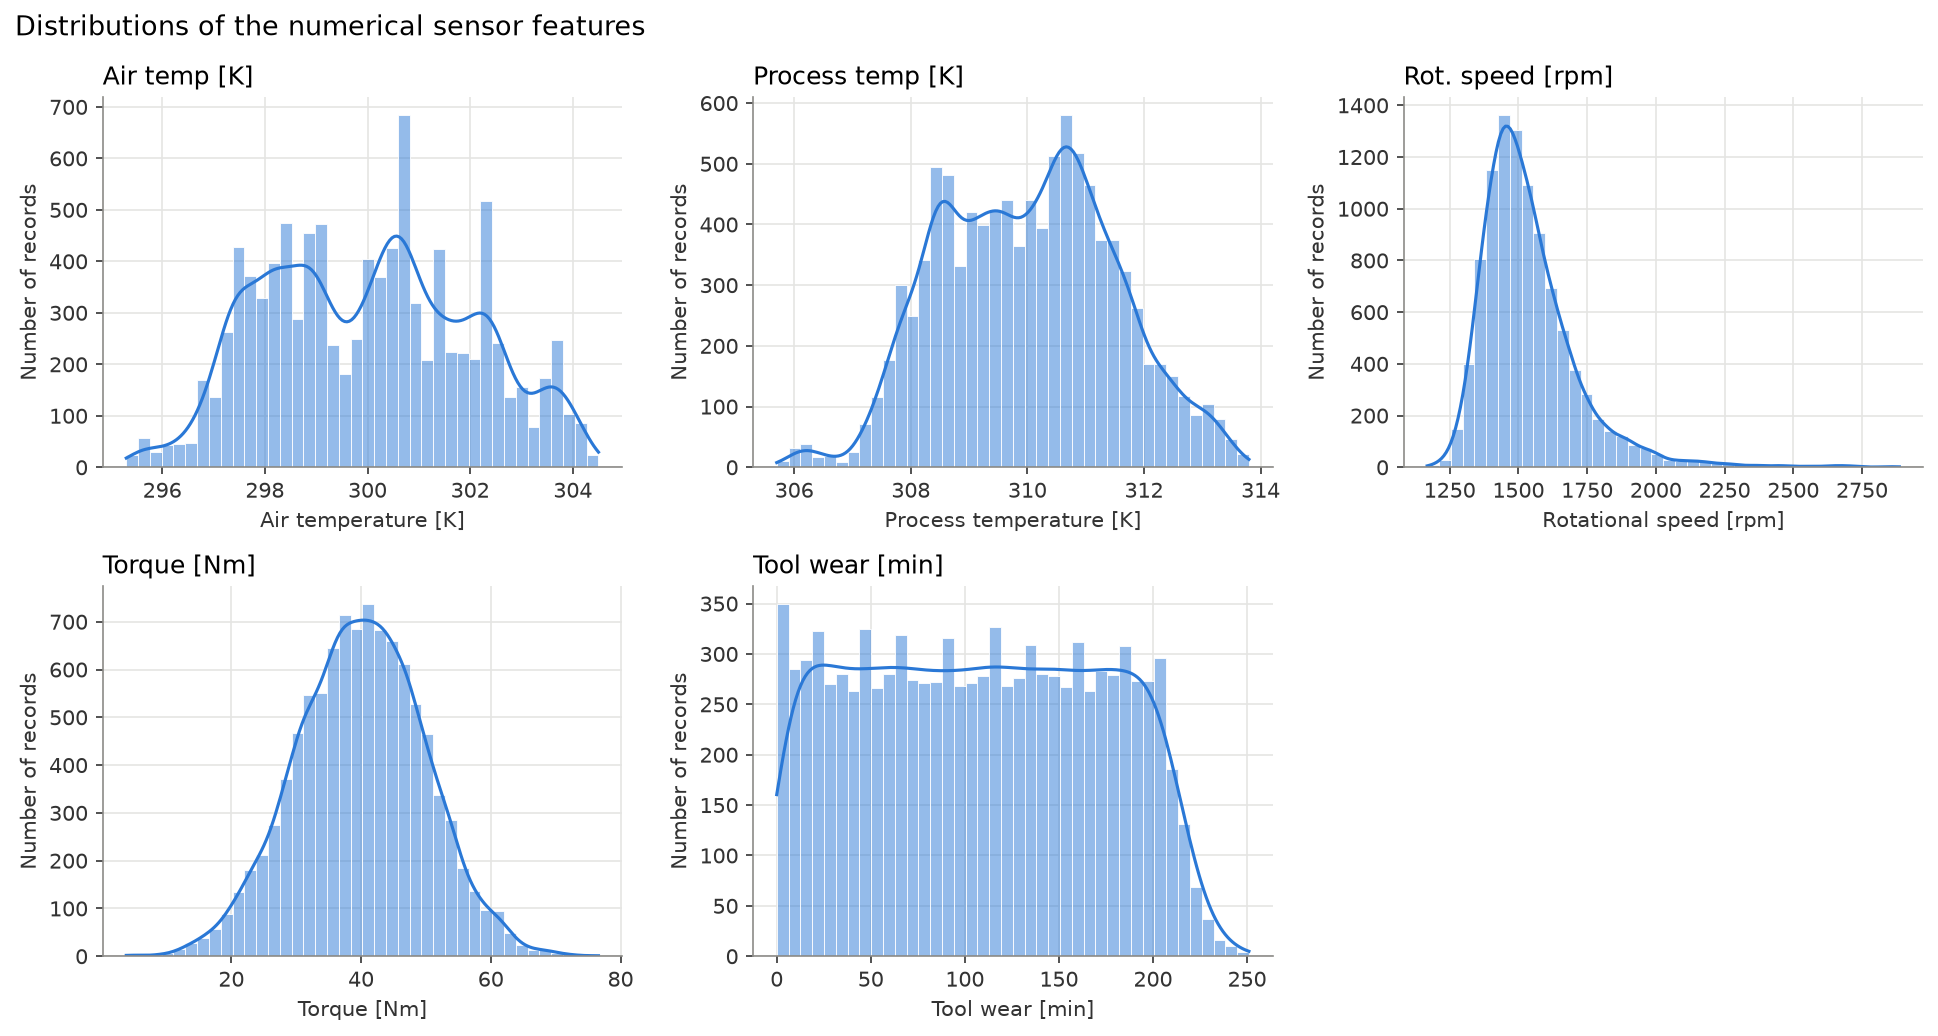

In [4]:
display(Image(filename=str(FIG / '04_numerical_distributions.png'), width=950))

**Finding.** Temperatures are roughly symmetric, tool wear is roughly uniform, torque is bell-shaped, and rotational speed is right-skewed with a long high-rpm tail.

## 4.3 Boxplots by failure type / outliers

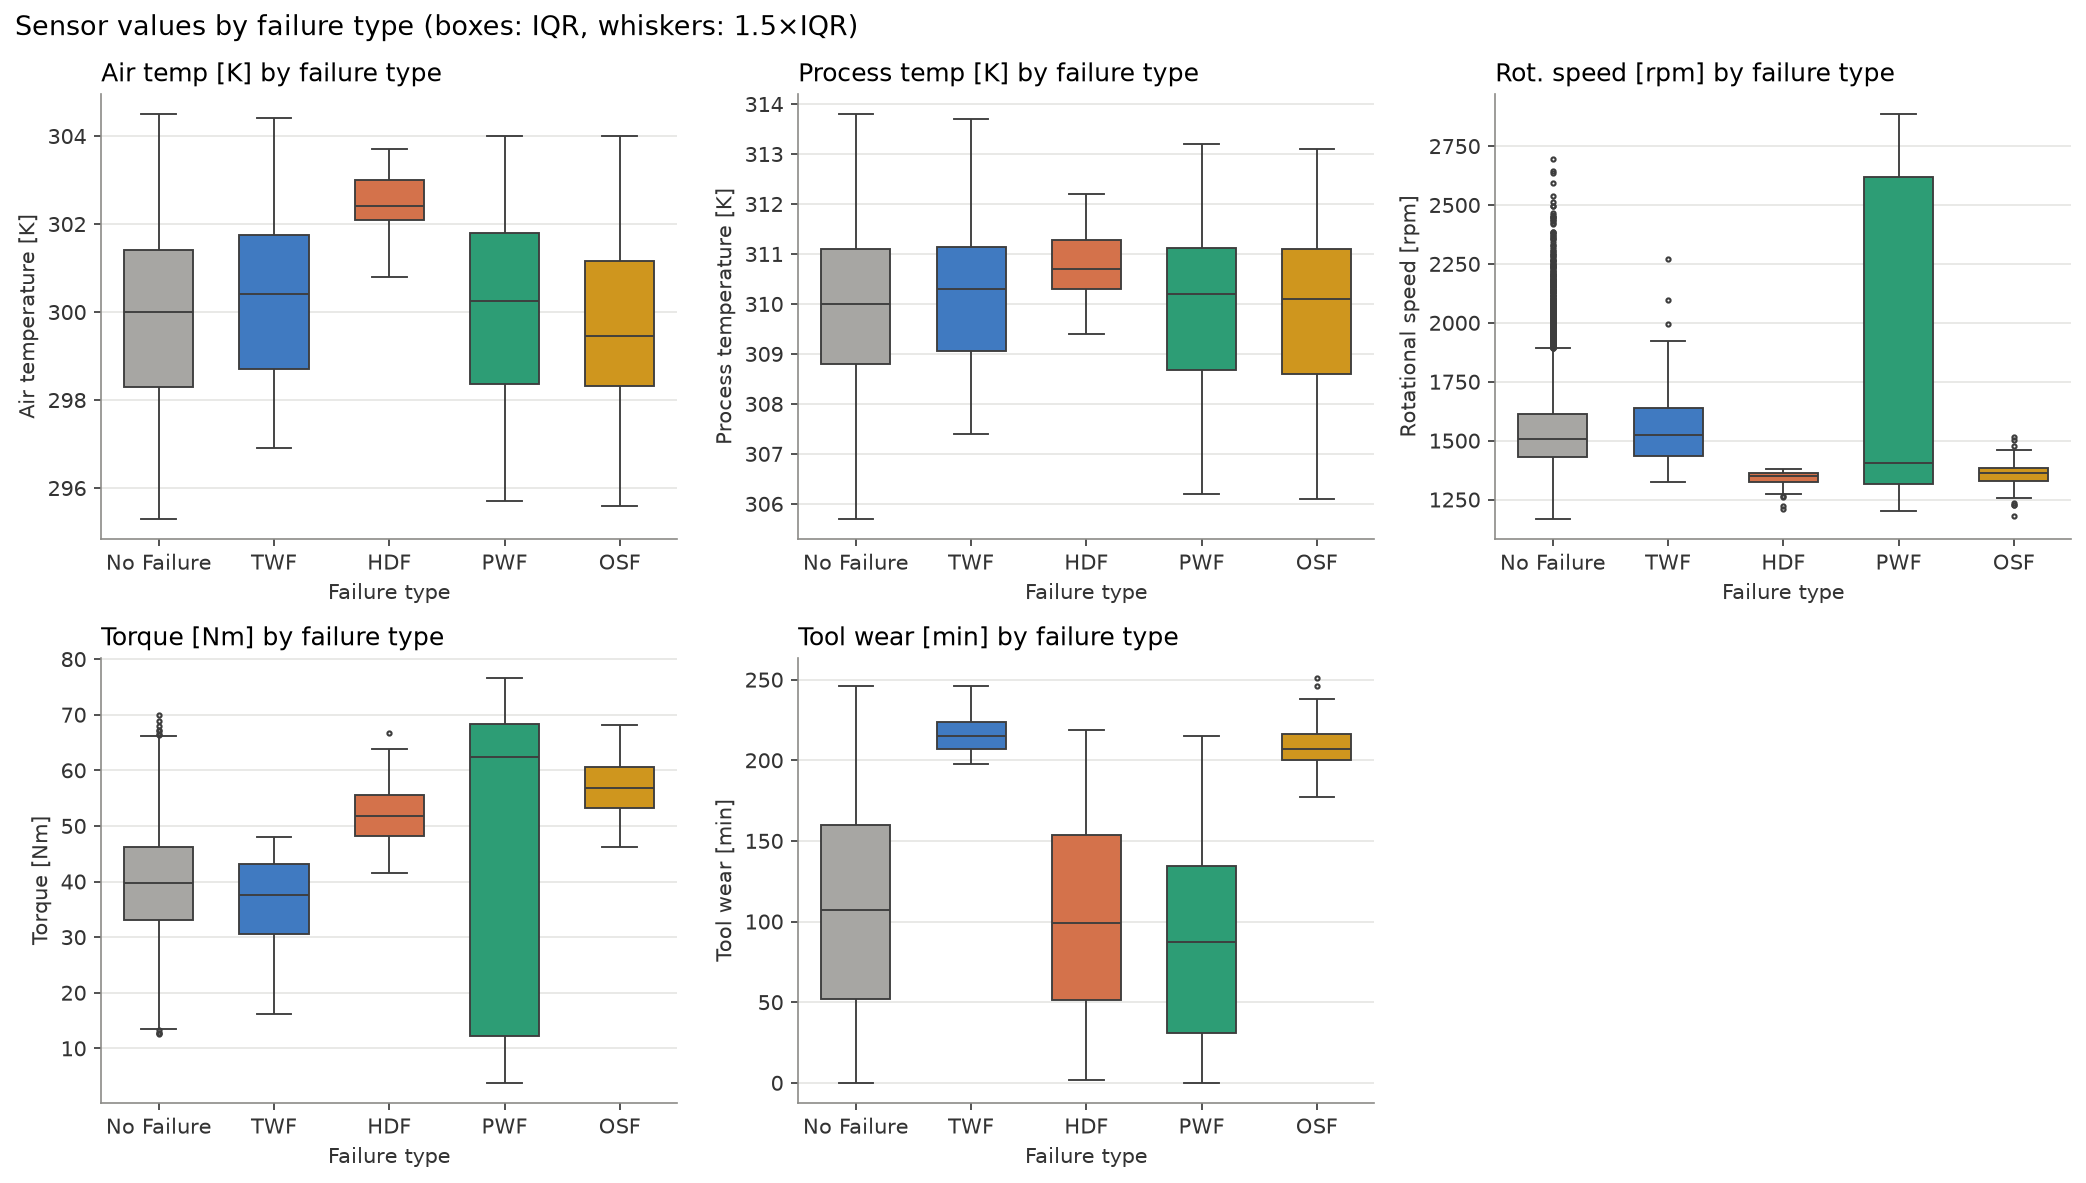

In [5]:
display(Image(filename=str(FIG / '04_boxplots_by_failure_type.png'), width=950))

**Finding.** Each failure mode occupies a distinct region: TWF and OSF at high tool wear, HDF at high air temperature and low rpm, PWF at both extremes of torque and speed. The high-rpm 'outliers' of No Failure are real operating points (see Stage 3 outlier table), not errors.

In [6]:
pd.read_csv(REP / 'stage3/outlier_summary.csv')

,feature,iqr_lower,iqr_upper,n_outliers,failure_rate_in_outliers_%,overall_failure_rate_%
0,Air temperature [K],293.50,306.30,0,NaN,3.39
1,Process temperature [K],305.35,314.55,0,NaN,3.39
2,Rotational speed [rpm],1139.50,1895.50,418,8.4,3.39
3,Torque [Nm],12.80,67.20,69,89.9,3.39
4,Tool wear [min],-110.50,325.50,0,NaN,3.39


## 4.4 Correlation

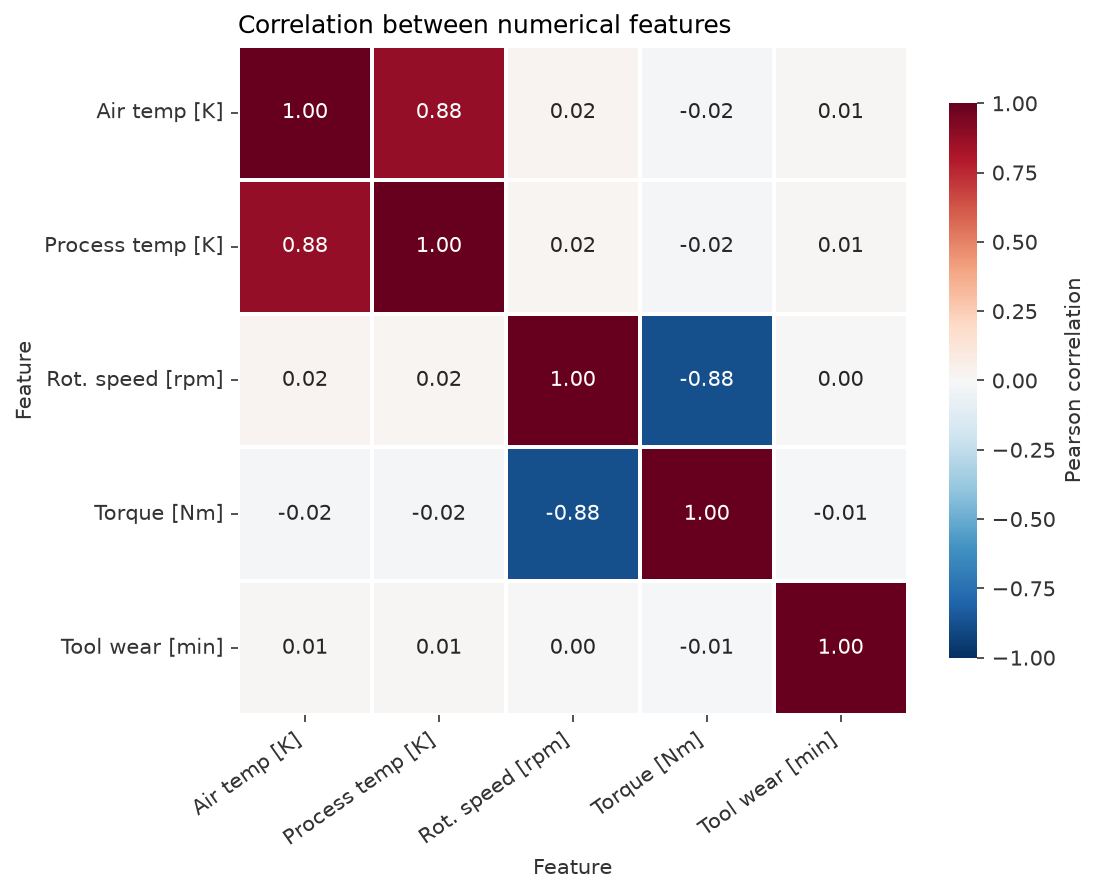

In [7]:
display(Image(filename=str(FIG / '04_correlation_heatmap.png'), width=600))

**Finding.** Two strong pairs: air vs process temperature (+0.88) and rotational speed vs torque (−0.88). All other correlations are near zero.

## 4.5 Feature vs failure type

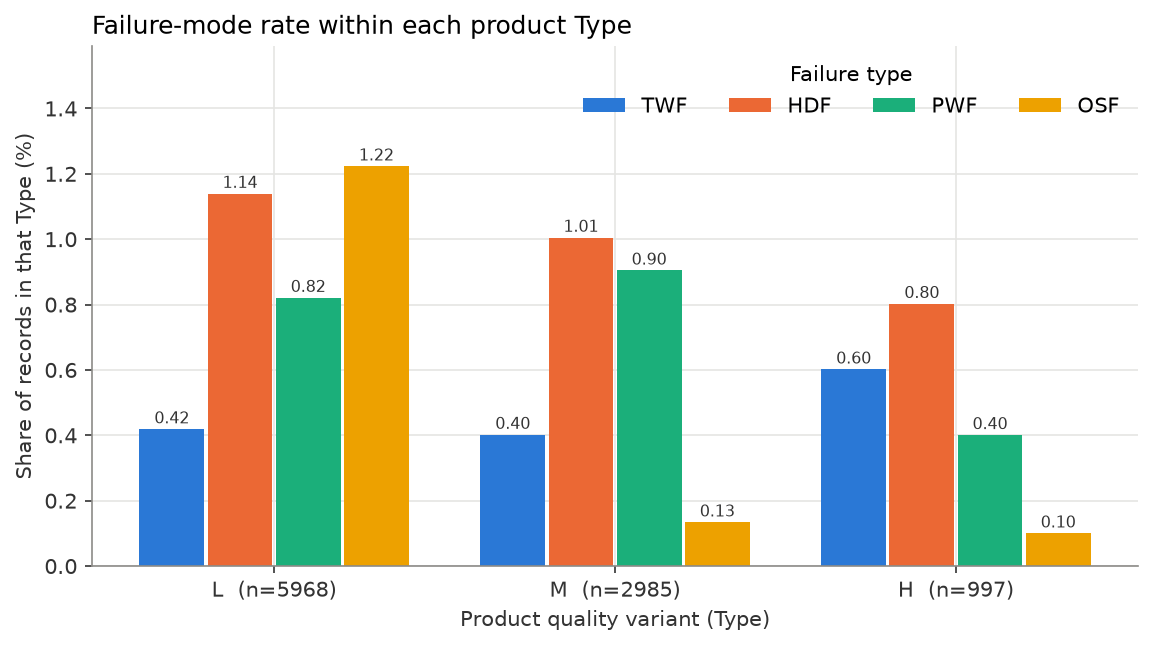

In [8]:
display(Image(filename=str(FIG / '04_failure_rate_by_type.png'), width=800))

In [9]:
pd.read_csv(REP / 'stage4/failure_rate_by_type_percent.csv', index_col=0)

,No Failure,TWF,HDF,PWF,OSF
Type,,,,,
L,96.397,0.419,1.139,0.821,1.223
M,97.554,0.402,1.005,0.905,0.134
H,98.094,0.602,0.802,0.401,0.100


**Finding.** OSF is about 10× more frequent in L-type products than in M or H, so `Type` carries information for OSF even though it is weak overall.

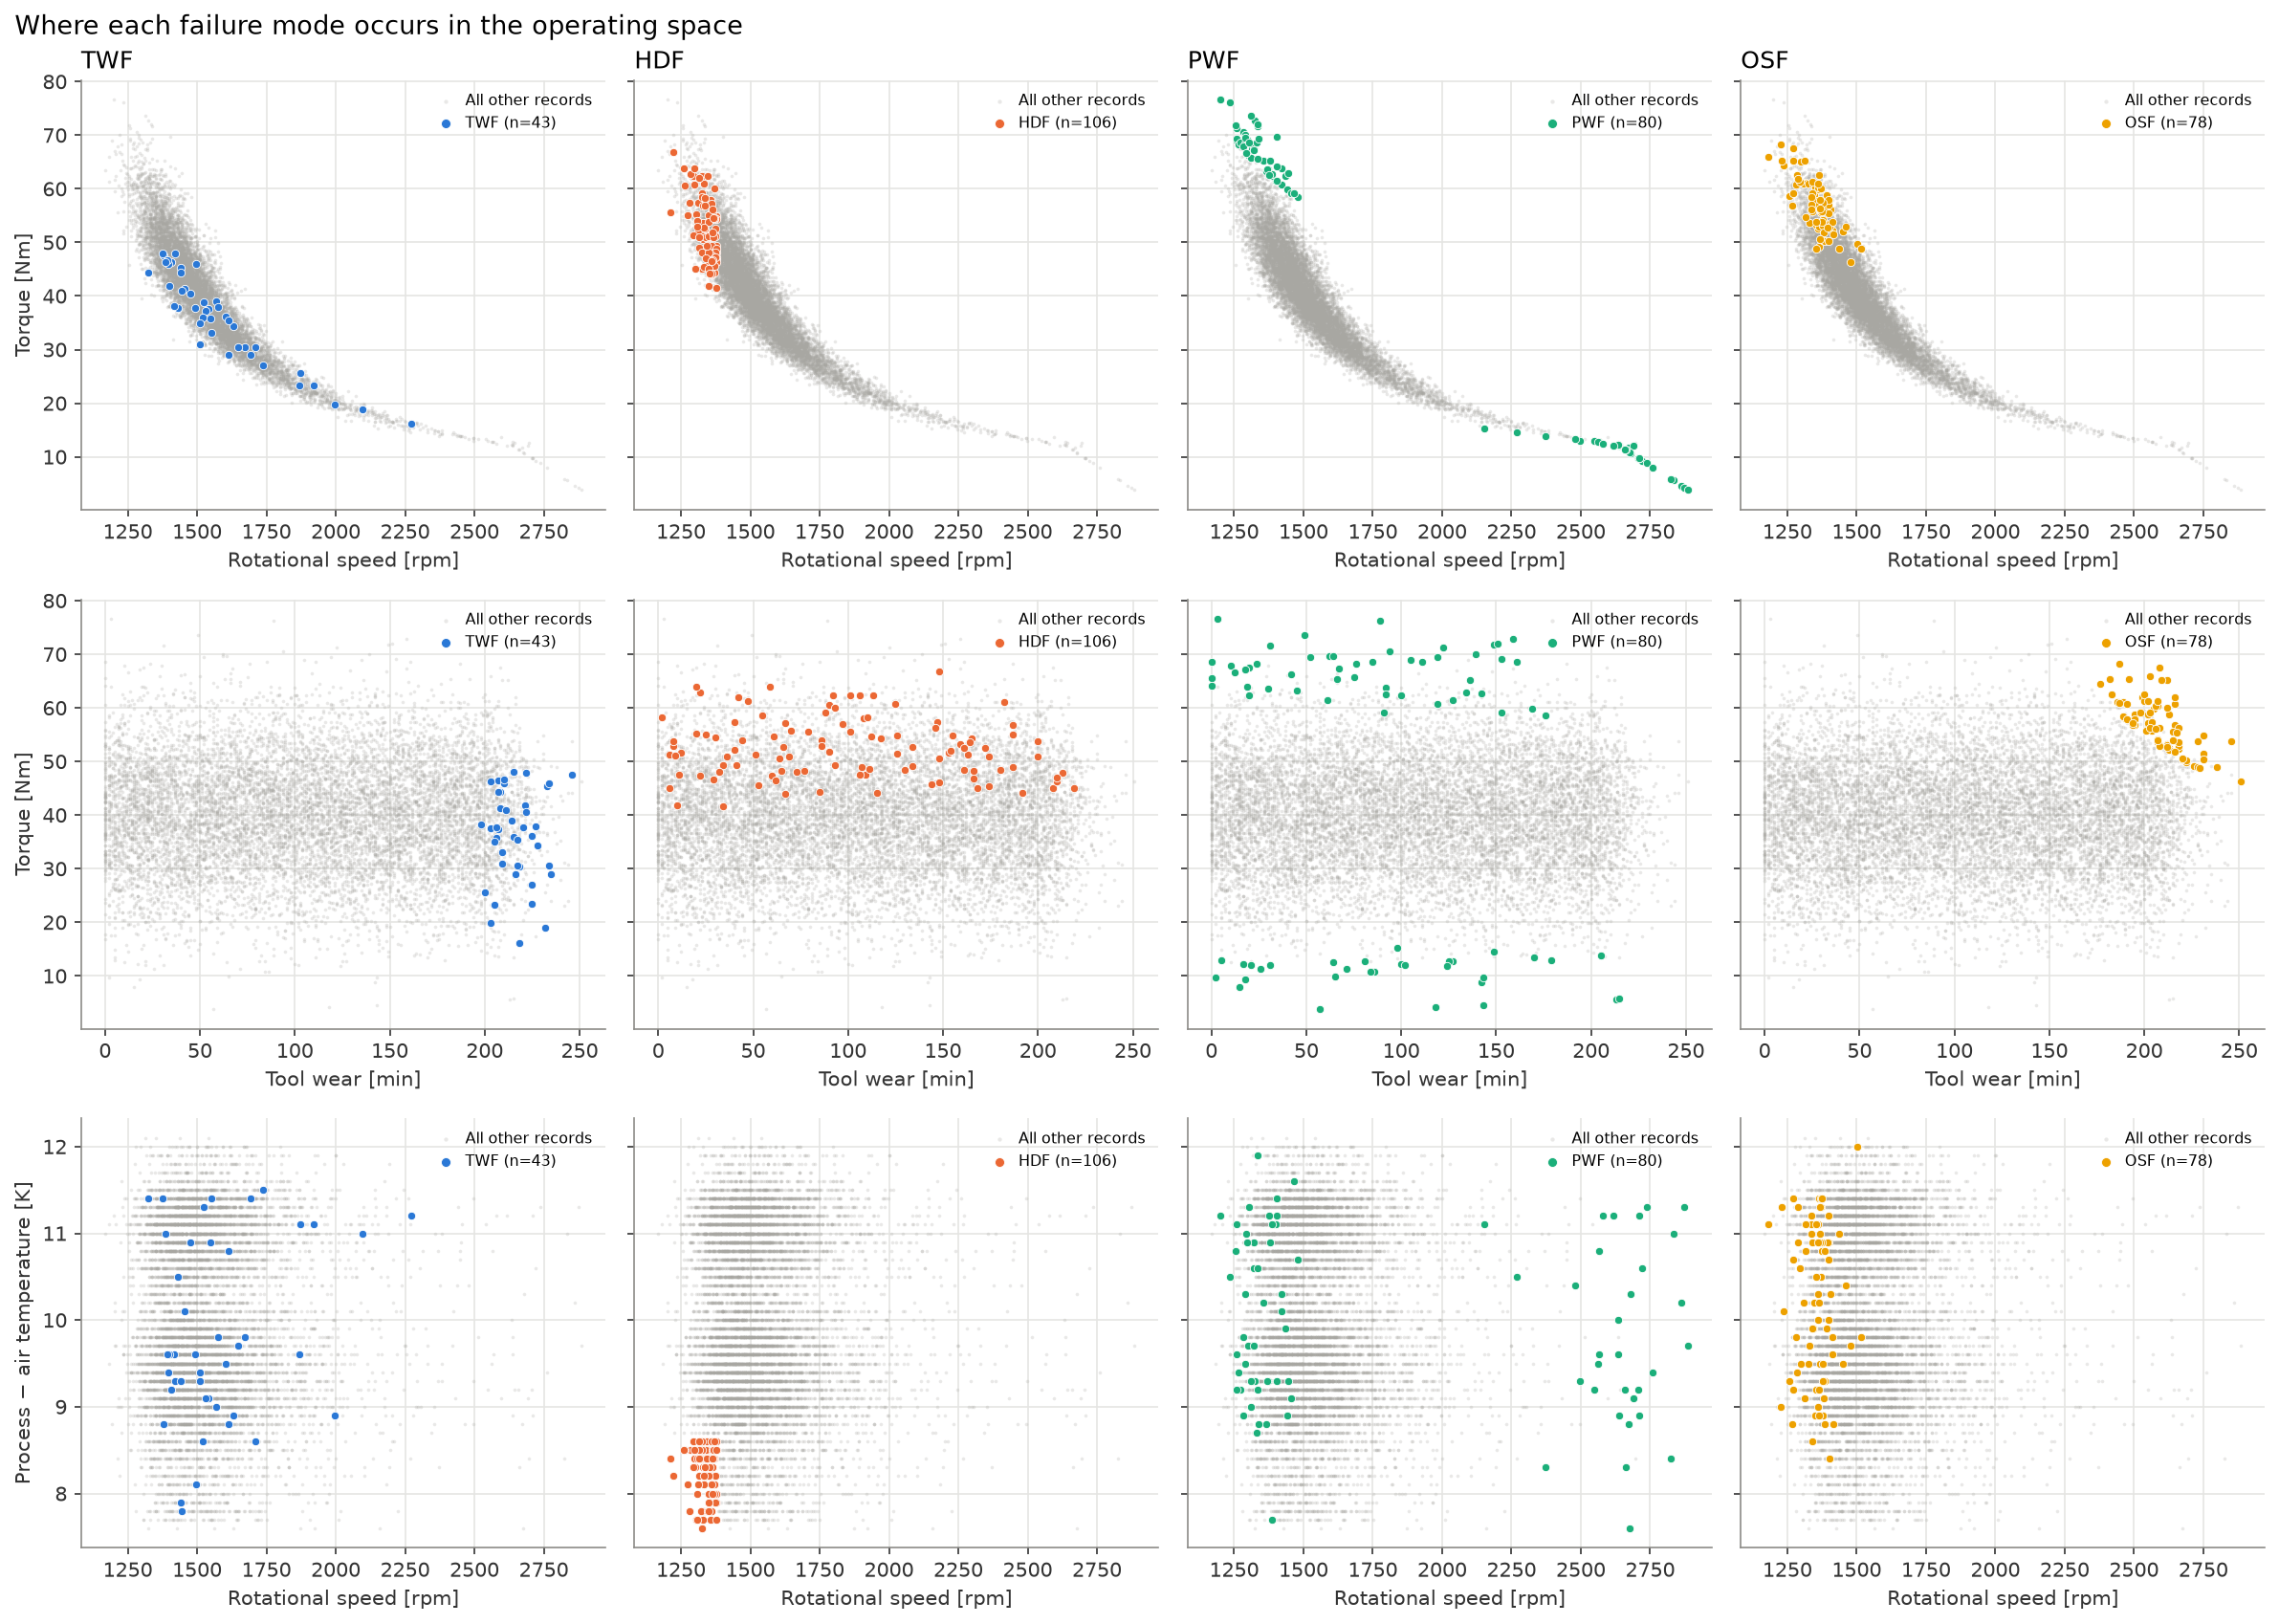

In [10]:
display(Image(filename=str(FIG / '04_parameter_space_by_failure_type.png'), width=1000))

In [11]:
pd.read_csv(REP / 'stage4/feature_medians_by_class.csv', index_col=0)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp difference [K],Power [W],Tool wear × torque [min·Nm]
Failure Type,,,,,,,,
No Failure,300.00,310.0,1507.0,39.80,107.0,9.8,6243.04,3951.20
TWF,300.40,310.3,1524.0,37.50,215.0,9.6,5976.25,7786.80
HDF,302.40,310.7,1349.0,51.75,99.0,8.3,7273.24,5313.45
PWF,300.25,310.2,1403.5,62.40,87.5,9.7,9042.23,2197.50
OSF,299.45,310.1,1362.5,56.75,207.0,10.2,8088.45,11545.40


**Findings.** (1) HDF sits at the smallest process−air temperature gaps and below ~1380 rpm. (2) PWF sits at both ends of the speed–torque curve, i.e. at extreme mechanical power. (3) OSF needs high tool wear *and* high torque. (4) TWF appears only at tool wear ≈ 200–246 min and otherwise overlaps No Failure, so it is expected to be the hardest class. These patterns motivate the engineered features in Stage 5.